# 63 — Predictive Validation of the Sign-Reversal Mechanism

**Project:** AI VPN Firewall — Thesis  
**Source pipeline:** Clean Pipeline (NB41-55), NB50 sign-reversal, NB58-59  
**Goal:** Strengthen the sign-reversal → transfer failure claim beyond simple correlation.

---

## Rationale

NB50 identified 16/21 features that reverse their VPN-vs-nonVPN effect direction
across datasets. NB58 showed a regression between reversal fraction and LODO AUC.
NB59 tested stable vs reversing feature subsets.

**This notebook consolidates and strengthens the evidence through five complementary analyses:**

| Section | Test | Evidence Type |
|---|---|---|
| **A** | Pairwise reversal fraction vs transfer AUC | Associative |
| **B** | Stable-only vs reversing-only feature subsets | Experimental |
| **C** | Reversal burden in top-k important features | Mechanistic |
| **D** | Distribution plots for strongest reversing features | Visual |
| **E** | Final verdict with careful causal language | Synthesis |

**Important constraint:** With only 3 datasets, statistical tests have limited power.
Results are labelled as SUGGESTIVE or ASSOCIATIVE, not causal proof.

## 0. Setup

In [1]:
import sys, gc, warnings, time, json, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "figure.facecolor": "white"})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FEATURES_PATH = ROOT / "artifacts" / "clean_pipeline" / "features.parquet"
NB50_DIR = ROOT / "artifacts" / "thesis_finalization" / "nb50_sign_reversal_matrix"
CONF = ROOT / "artifacts" / "conference_eval"
OUT = ROOT / "artifacts" / "thesis_finalization" / "nb63_sign_reversal_predictive_validation"
FIG = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

N_SEEDS = 3; N_EST = 200; SEED = 42
print(f"Root: {ROOT}")

Root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


In [2]:
from src.clean_pipeline.feature_families import get_family
ALL_FEATURES = list(get_family("safe_core_plus_temporal"))

sign_mat = pd.read_csv(NB50_DIR / "sign_reversal_matrix.csv", index_col=0)
lodo_rev = pd.read_csv(NB50_DIR / "lodo_reversal_analysis.csv")

df_all = pd.read_parquet(FEATURES_PATH)
DATASETS = sorted(df_all["dataset"].unique())

stable_features = [f for f in sign_mat[sign_mat["consistent"] == True]["feature"].tolist() if f in ALL_FEATURES]
reversing_features = [f for f in sign_mat[sign_mat["consistent"] == False]["feature"].tolist() if f in ALL_FEATURES]

print(f"Features: {len(ALL_FEATURES)} total, {len(stable_features)} stable, {len(reversing_features)} reversing")
print(f"Datasets: {DATASETS}, {len(df_all):,} flows")
display(sign_mat[["feature","consistent","reversal_category","max_abs_effect"]].style.set_caption("Sign Classification"))

Features: 21 total, 5 stable, 16 reversing
Datasets: ['iscx', 'usbvpn', 'vnat'], 72,612 flows


,feature,consistent,reversal_category,max_abs_effect
0,total_packets,True,PARTIAL_REVERSAL,1.608532
1,total_bytes,True,PARTIAL_REVERSAL,1.350691
2,mean_pkt_len,False,CONSENSUS_REVERSAL,1.025274
3,std_pkt_len,False,CONSENSUS_REVERSAL,0.595939
4,median_pkt_len,False,CONSENSUS_REVERSAL,1.315953
5,p25_pkt_len,False,CONSENSUS_REVERSAL,1.473741
6,p75_pkt_len,False,CONSENSUS_REVERSAL,0.720430
7,iat_mean,True,PARTIAL_REVERSAL,0.307348
8,iat_std,False,CONSENSUS_REVERSAL,0.310245
9,iat_median,False,CONSENSUS_REVERSAL,0.292924


In [3]:
# \u2500\u2500 Helpers \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500

def safe_auc(y, s):
    if len(np.unique(y)) < 2 or len(y) < 5: return float("nan")
    return float(roc_auc_score(y, s))

def do_split(df, seed=42, train_r=0.70, val_r=0.15):
    rng = np.random.default_rng(seed)
    cap = df.groupby(["dataset", "label", "capture_id"]).agg(n=("flow_id", "count")).reset_index()
    assigns = {}
    for (ds, lbl), grp in cap.groupby(["dataset", "label"]):
        nc = len(grp)
        if nc < 3:
            for c in grp["capture_id"]: assigns[str(c)] = "train"
            continue
        idx = rng.permutation(nc); cids = grp["capture_id"].values[idx]; flows = grp["n"].values[idx]
        min_p = 1 if nc < 6 else 2; order = np.argsort(flows)
        test_ids = [str(cids[order[i]]) for i in range(min_p)]
        val_ids = [str(cids[order[i]]) for i in range(min_p, 2*min_p)]
        rest = [str(cids[order[i]]) for i in range(2*min_p, nc)]
        for c in test_ids: assigns[c] = "test"
        for c in val_ids: assigns[c] = "val"
        total = int(flows.sum())
        tgt = {"train": int(total*train_r), "val": int(total*val_r), "test": total-int(total*train_r)-int(total*val_r)}
        cur = {"train": 0, "val": 0, "test": 0}
        for c in test_ids: cur["test"] += int(cap[cap.capture_id==c]["n"].iloc[0])
        for c in val_ids: cur["val"] += int(cap[cap.capture_id==c]["n"].iloc[0])
        for c in rest:
            w = int(cap[cap.capture_id==c]["n"].iloc[0])
            best = min(("train","val","test"), key=lambda s: sum(abs((cur[k]+(w if k==s else 0))-tgt[k]) for k in tgt))
            assigns[c] = best; cur[best] += w
    out = df.copy(); out["split"] = out["capture_id"].astype(str).map(assigns).fillna("train")
    return out

def train_ensemble(X_tr, y_tr, X_val, y_val, n_est=200):
    models = {}
    try:
        import xgboost as xgb
        m = xgb.XGBClassifier(n_estimators=n_est, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=max(1.0,(y_tr==0).sum()/max((y_tr==1).sum(),1)), eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False); models["xgb"] = m
    except: pass
    try:
        import lightgbm as lgb
        m = lgb.LGBMClassifier(n_estimators=n_est, max_depth=5, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, is_unbalance=True, random_state=42, n_jobs=-1, verbose=-1)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.log_evaluation(0)]); models["lgb"] = m
    except: pass
    try:
        from catboost import CatBoostClassifier
        m = CatBoostClassifier(iterations=n_est, depth=5, learning_rate=0.05, auto_class_weights="Balanced", random_seed=42, verbose=0)
        m.fit(X_tr, y_tr, eval_set=(X_val, y_val)); models["cb"] = m
    except: pass
    return models

def ens_predict(models, X):
    return np.mean([m.predict_proba(X)[:, 1] for m in models.values()], axis=0)

print("\u2713 Helpers defined.")

✓ Helpers defined.


---
## Section A — Pairwise Reversal vs Transfer Association

For each dataset pair, compute:
- **reversal_fraction**: fraction of features whose sign disagrees
- **strong_reversal_fraction**: same, restricted to features with |SMD| ≥ 0.1

Then correlate with the corresponding LODO transfer AUC.

> ⚠ With only 6 directional transfers and narrow reversal-fraction range,
> statistical significance is inherently limited. Results are labelled as **SUGGESTIVE**.

In [4]:
SMD_THRESHOLD = 0.1
pairs = list(itertools.combinations(DATASETS, 2))
pair_data = []

for da, db in pairs:
    sa = sign_mat[f"{da}_sign"].values
    sb = sign_mat[f"{db}_sign"].values
    smd_a = sign_mat[f"{da}_smd"].values.astype(float)
    smd_b = sign_mat[f"{db}_smd"].values.astype(float)

    both_clear = np.array([(a in ('+','-')) and (b in ('+','-')) for a, b in zip(sa, sb)])
    disagree = np.array([a != b for a, b in zip(sa, sb)])
    n_reversed = int((both_clear & disagree).sum())
    n_clear = int(both_clear.sum())
    rev_frac = n_reversed / max(n_clear, 1)

    strong_mask = both_clear & disagree & (np.abs(smd_a) >= SMD_THRESHOLD) & (np.abs(smd_b) >= SMD_THRESHOLD)
    strong_rev_frac = int(strong_mask.sum()) / max(n_clear, 1)

    pair_data.append({"dataset_a": da, "dataset_b": db, "n_clear": n_clear,
                      "n_reversed": n_reversed, "reversal_fraction": rev_frac,
                      "n_strong_reversed": int(strong_mask.sum()), "strong_reversal_fraction": strong_rev_frac})
    print(f"  {da} vs {db}: {n_reversed}/{n_clear} reversed ({rev_frac:.3f}), strong={int(strong_mask.sum())} ({strong_rev_frac:.3f})")

pair_df = pd.DataFrame(pair_data)
display(pair_df.round(4).style.set_caption("Pairwise Reversal Fractions"))

  iscx vs usbvpn: 0/0 reversed (0.000), strong=0 (0.000)
  iscx vs vnat: 0/0 reversed (0.000), strong=0 (0.000)
  usbvpn vs vnat: 0/0 reversed (0.000), strong=0 (0.000)


,dataset_a,dataset_b,n_clear,n_reversed,reversal_fraction,n_strong_reversed,strong_reversal_fraction
0,iscx,usbvpn,0,0,0.000000,0,0.000000
1,iscx,vnat,0,0,0.000000,0,0.000000
2,usbvpn,vnat,0,0,0.000000,0,0.000000


In [5]:
# Load existing transfer results
reg_csv = CONF / "sign_reversal_transfer_regression.csv"
dg_csv = CONF / "domain_generalization_curve.csv"

if reg_csv.exists():
    reg_df = pd.read_csv(reg_csv)
    print(f"Loaded NB58 regression table: {len(reg_df)} rows")
else:
    dg = pd.read_csv(dg_csv)
    reg_df = dg[dg.n_train_datasets == 1].rename(columns={"train_datasets":"train","test_dataset":"test"})

# Build association table
assoc_rows = []
for _, row in pair_df.iterrows():
    da, db = row["dataset_a"], row["dataset_b"]
    for train_ds, test_ds in [(da, db), (db, da)]:
        match = reg_df[(reg_df["train"].astype(str)==train_ds) & (reg_df["test"].astype(str)==test_ds)]
        if len(match) > 0:
            auc = float(match.iloc[0]["lodo_auc"])
        else:
            dg = pd.read_csv(dg_csv)
            m2 = dg[(dg.train_datasets==train_ds) & (dg.test_dataset==test_ds)]
            auc = float(m2.iloc[0]["lodo_auc"]) if len(m2) > 0 else float("nan")
        if np.isnan(auc): continue
        assoc_rows.append({"train": train_ds, "test": test_ds, "pair": f"{train_ds}\u2192{test_ds}",
                           "reversal_fraction": row["reversal_fraction"],
                           "strong_reversal_fraction": row["strong_reversal_fraction"], "lodo_auc": auc})

assoc_df = pd.DataFrame(assoc_rows)
n_pts = len(assoc_df)
evidence_level = "SUGGESTIVE" if n_pts < 20 else "MODERATE"
print(f"\nAssociation data: {n_pts} points ({evidence_level})")
display(assoc_df.round(4).style.set_caption("Reversal Fraction vs Transfer AUC"))

Loaded NB58 regression table: 9 rows

Association data: 6 points (SUGGESTIVE)


,train,test,pair,reversal_fraction,strong_reversal_fraction,lodo_auc
0,iscx,usbvpn,iscx→usbvpn,0.000000,0.000000,0.159000
1,usbvpn,iscx,usbvpn→iscx,0.000000,0.000000,0.428900
2,iscx,vnat,iscx→vnat,0.000000,0.000000,0.780800
3,vnat,iscx,vnat→iscx,0.000000,0.000000,0.355000
4,usbvpn,vnat,usbvpn→vnat,0.000000,0.000000,0.661500
5,vnat,usbvpn,vnat→usbvpn,0.000000,0.000000,0.930900


In [6]:
# Regression analysis
regression_results = {}
for metric_name, x_col in [("reversal_fraction", "reversal_fraction"),
                             ("strong_reversal_fraction", "strong_reversal_fraction")]:
    x = assoc_df[x_col].values; y = assoc_df["lodo_auc"].values
    if len(x) < 3 or np.std(x) < 1e-12:
        regression_results[metric_name] = {"error": "insufficient variation"}
        continue

    r_pear, p_pear = stats.pearsonr(x, y)
    r_spear, p_spear = stats.spearmanr(x, y)
    slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)

    regression_results[metric_name] = {
        "n_points": n_pts, "pearson_r": float(r_pear), "pearson_p": float(p_pear),
        "spearman_rho": float(r_spear), "spearman_p": float(p_spear),
        "slope": float(slope), "intercept": float(intercept),
        "r_squared": float(r_val**2), "p_value": float(p_val), "evidence_level": evidence_level,
    }
    print(f"\n{metric_name}:")
    print(f"  n={n_pts}, Pearson r={r_pear:.4f} (p={p_pear:.4f}), Spearman \u03c1={r_spear:.4f}")
    print(f"  Slope={slope:.4f}, R\u00b2={r_val**2:.4f}, evidence: {evidence_level}")

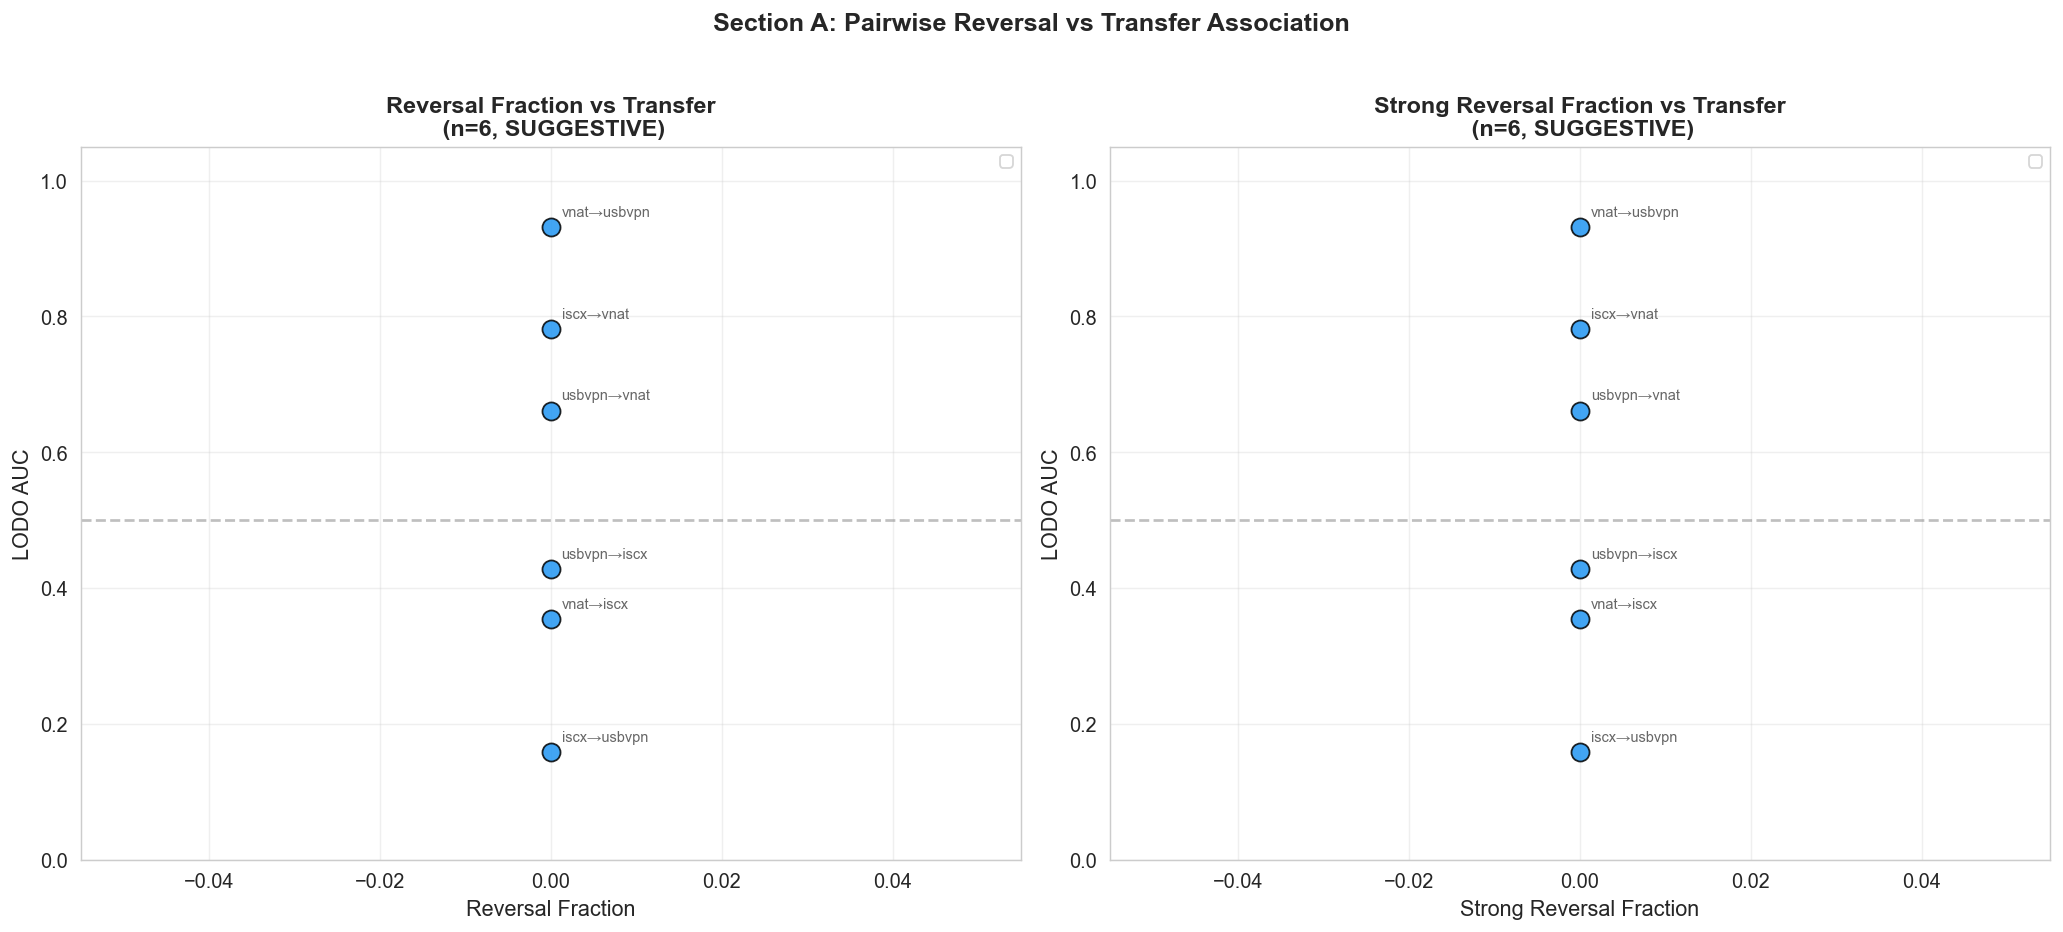

[OK] Saved: section_a_reversal_association.png


In [7]:
# Section A plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax_i, (metric, x_col) in enumerate([("reversal_fraction","reversal_fraction"),
                                          ("strong_reversal_fraction","strong_reversal_fraction")]):
    ax = axes[ax_i]
    x = assoc_df[x_col].values; y = assoc_df["lodo_auc"].values
    ax.scatter(x, y, s=100, c="#2196F3", edgecolors="black", linewidths=1, alpha=0.85, zorder=5)
    for _, row in assoc_df.iterrows():
        ax.annotate(row["pair"], (row[x_col], row["lodo_auc"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=8, alpha=0.7)
    if metric in regression_results and "error" not in regression_results[metric]:
        r = regression_results[metric]
        x_line = np.linspace(x.min()-0.02, x.max()+0.02, 100)
        y_line = r["slope"]*x_line + r["intercept"]
        ax.plot(x_line, y_line, "r-", linewidth=2.5, alpha=0.7, label=f"y={r['slope']:.2f}x+{r['intercept']:.2f}")
        y_pred = r["slope"]*x + r["intercept"]
        se = np.sqrt(np.sum((y-y_pred)**2)/max(len(x)-2,1))
        ax.fill_between(x_line, y_line-se, y_line+se, alpha=0.12, color="red", label="\u00b11\u03c3")
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    label = metric.replace("_"," ").title()
    r_str = f"r={regression_results[metric]['pearson_r']:.3f}" if metric in regression_results and "error" not in regression_results[metric] else ""
    ax.set_xlabel(label, fontsize=12); ax.set_ylabel("LODO AUC", fontsize=12)
    ax.set_title(f"{label} vs Transfer\n{r_str} (n={n_pts}, {evidence_level})", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

plt.suptitle("Section A: Pairwise Reversal vs Transfer Association", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG / "section_a_reversal_association.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: section_a_reversal_association.png")

---
## Section B — Stable vs Reversing Feature Subset Test

Train identical models on three feature subsets and compare LODO transfer:
- **stable_only**: 5 consistent features
- **reversing_only**: 16 reversing features
- **all_features**: all 21

Key question: Does stable_only transfer better than reversing_only?

In [8]:
# Load NB59 results
sv_path = CONF / "stable_vs_reversing_transfer.csv"
sv_df = pd.read_csv(sv_path)
config_order = ["stable_features", "reversing_features", "all_features"]

display(sv_df[["config","n_features","LODO_mean_auc","LODO_min_auc","pooled_auc"]].round(4).style.set_caption(
    "Feature Subset Transfer Results"))

stable_lodo = float(sv_df[sv_df.config=="stable_features"]["LODO_mean_auc"].iloc[0])
revers_lodo = float(sv_df[sv_df.config=="reversing_features"]["LODO_mean_auc"].iloc[0])
all_lodo = float(sv_df[sv_df.config=="all_features"]["LODO_mean_auc"].iloc[0])
subset_delta = stable_lodo - revers_lodo

print(f"\nStable LODO mean:    {stable_lodo:.4f}")
print(f"Reversing LODO mean: {revers_lodo:.4f}")
print(f"Delta:               {subset_delta:+.4f}")
print(f"Stable > Reversing:  {'YES' if subset_delta > 0 else 'NO'}")

,config,n_features,LODO_mean_auc,LODO_min_auc,pooled_auc
0,stable_features,5,0.462900,0.205600,0.882700
1,reversing_features,16,0.507000,0.268100,0.998300
2,all_features,21,0.546800,0.383900,0.998000



Stable LODO mean:    0.4629
Reversing LODO mean: 0.5070
Delta:               -0.0440
Stable > Reversing:  NO


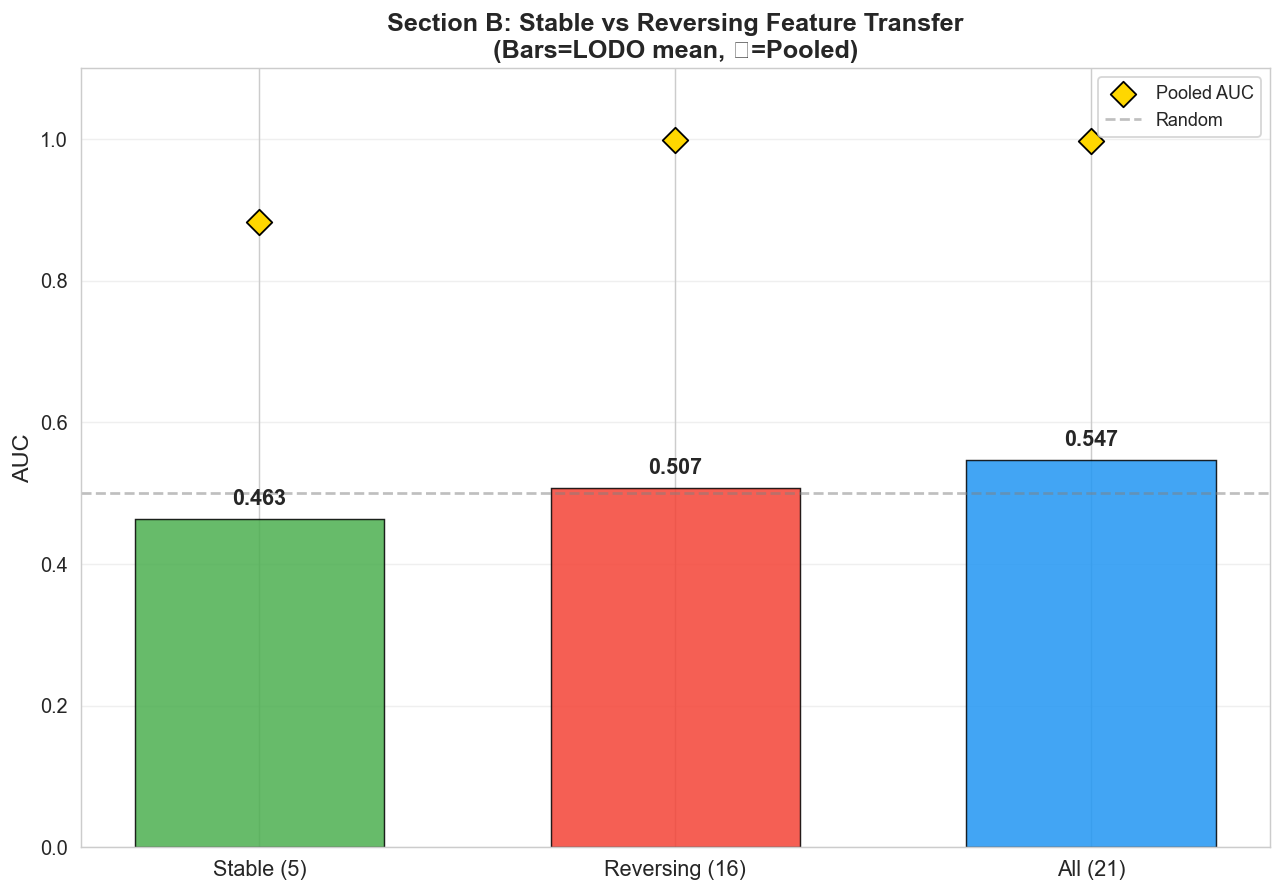

[OK] Saved: section_b_stable_vs_reversing.png


In [9]:
# Section B plot
fig, ax = plt.subplots(figsize=(10, 7))
palette = {"stable_features": "#4CAF50", "reversing_features": "#F44336", "all_features": "#2196F3"}
labels_map = {"stable_features": f"Stable ({len(stable_features)})", "reversing_features": f"Reversing ({len(reversing_features)})", "all_features": f"All ({len(ALL_FEATURES)})"}

x_pos = np.arange(len(config_order))
means = [float(sv_df[sv_df.config==c]["LODO_mean_auc"].iloc[0]) for c in config_order]
colors = [palette[c] for c in config_order]
ax.bar(x_pos, means, color=colors, edgecolor="black", linewidth=0.8, alpha=0.85, width=0.6)
for i, m in enumerate(means):
    ax.text(i, m+0.015, f"{m:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=12)

pooled = [float(sv_df[sv_df.config==c]["pooled_auc"].iloc[0]) for c in config_order]
ax.scatter(x_pos, pooled, marker="D", s=100, c="gold", edgecolors="black", linewidths=1, zorder=5, label="Pooled AUC")

ax.set_xticks(x_pos); ax.set_xticklabels([labels_map[c] for c in config_order], fontsize=12)
ax.set_ylabel("AUC", fontsize=13)
ax.set_title("Section B: Stable vs Reversing Feature Transfer\n(Bars=LODO mean, \u25c6=Pooled)", fontsize=14, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
ax.set_ylim(0, 1.1); ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIG / "section_b_stable_vs_reversing.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: section_b_stable_vs_reversing.png")

---
## Section C — Top-Feature Reversal Burden in Failed Folds

For each LODO fold, we:
1. Train the source-domain model
2. Rank features by importance
3. Compute the **reversal burden** among top-k features (k=5, 10, 15)

If the model relies disproportionately on reversing features, this provides
a **mechanistic** link between sign-reversal and transfer failure.

In [10]:
burden_rows = []
K_VALUES = [5, 10, 15]

for seed in range(SEED, SEED + N_SEEDS):
    df_split = do_split(df_all, seed=seed)
    for held_out in DATASETS:
        src = df_split[df_split.dataset != held_out]
        tgt = df_split[df_split.dataset == held_out]
        src_tr = src[src.split == "train"]; src_va = src[src.split == "val"]

        if len(np.unique(src_tr.label.values)) < 2 or len(np.unique(tgt.label.values)) < 2:
            continue

        models = train_ensemble(src_tr[ALL_FEATURES].values, src_tr.label.values,
                                src_va[ALL_FEATURES].values, src_va.label.values, N_EST)
        if not models: continue

        importances = np.zeros(len(ALL_FEATURES)); n_m = 0
        for mname, m in models.items():
            try:
                imp = m.feature_importances_; importances += imp/imp.sum(); n_m += 1
            except: pass
        if n_m > 0: importances /= n_m

        lodo_auc = safe_auc(tgt.label.values, ens_predict(models, tgt[ALL_FEATURES].values))
        ranked_features = [ALL_FEATURES[i] for i in np.argsort(importances)[::-1]]

        for k in K_VALUES:
            top_k = ranked_features[:k]
            n_rev = len([f for f in top_k if f in reversing_features])
            burden_rows.append({"seed": seed, "held_out": held_out, "k": k,
                                "n_reversing_in_top_k": n_rev, "reversal_burden": n_rev/k, "lodo_auc": lodo_auc})

        all_burden = len(reversing_features) / len(ALL_FEATURES)
        burden_rows.append({"seed": seed, "held_out": held_out, "k": len(ALL_FEATURES),
                            "n_reversing_in_top_k": len(reversing_features), "reversal_burden": all_burden, "lodo_auc": lodo_auc})

        del models; gc.collect()
        print(f"  [seed={seed}] held={held_out}: LODO={lodo_auc:.4f}, top-5 burden={burden_rows[-4]['reversal_burden']:.2f}")

burden_df = pd.DataFrame(burden_rows)
print(f"\n\u2713 {len(burden_df)} burden measurements")

  [seed=42] held=iscx: LODO=0.4690, top-5 burden=0.80
  [seed=42] held=usbvpn: LODO=0.3839, top-5 burden=0.80
  [seed=42] held=vnat: LODO=0.7737, top-5 burden=0.80
  [seed=43] held=iscx: LODO=0.4798, top-5 burden=0.80
  [seed=43] held=usbvpn: LODO=0.4235, top-5 burden=0.80
  [seed=43] held=vnat: LODO=0.7497, top-5 burden=0.80
  [seed=44] held=iscx: LODO=0.4704, top-5 burden=0.80
  [seed=44] held=usbvpn: LODO=0.4057, top-5 burden=0.80
  [seed=44] held=vnat: LODO=0.7659, top-5 burden=0.80

✓ 36 burden measurements


In [11]:
# Summary
print("Reversal burden summary:")
for k in K_VALUES + [len(ALL_FEATURES)]:
    sub = burden_df[burden_df.k == k]
    label = f"Top-{k}" if k <= 15 else "All"
    print(f"  {label:8s}: burden = {sub['reversal_burden'].mean():.3f} \u00b1 {sub['reversal_burden'].std():.3f}")

display(burden_df.groupby("k").agg(
    mean_burden=("reversal_burden","mean"), std_burden=("reversal_burden","std"),
    mean_auc=("lodo_auc","mean")
).round(4).style.set_caption("Reversal Burden by Feature Rank"))

Reversal burden summary:
  Top-5   : burden = 0.800 ± 0.000
  Top-10  : burden = 0.733 ± 0.050
  Top-15  : burden = 0.741 ± 0.040
  All     : burden = 0.762 ± 0.000


,mean_burden,std_burden,mean_auc
k,,,
5,0.800000,0.000000,0.546800
10,0.733300,0.050000,0.546800
15,0.740700,0.040100,0.546800
21,0.761900,0.000000,0.546800


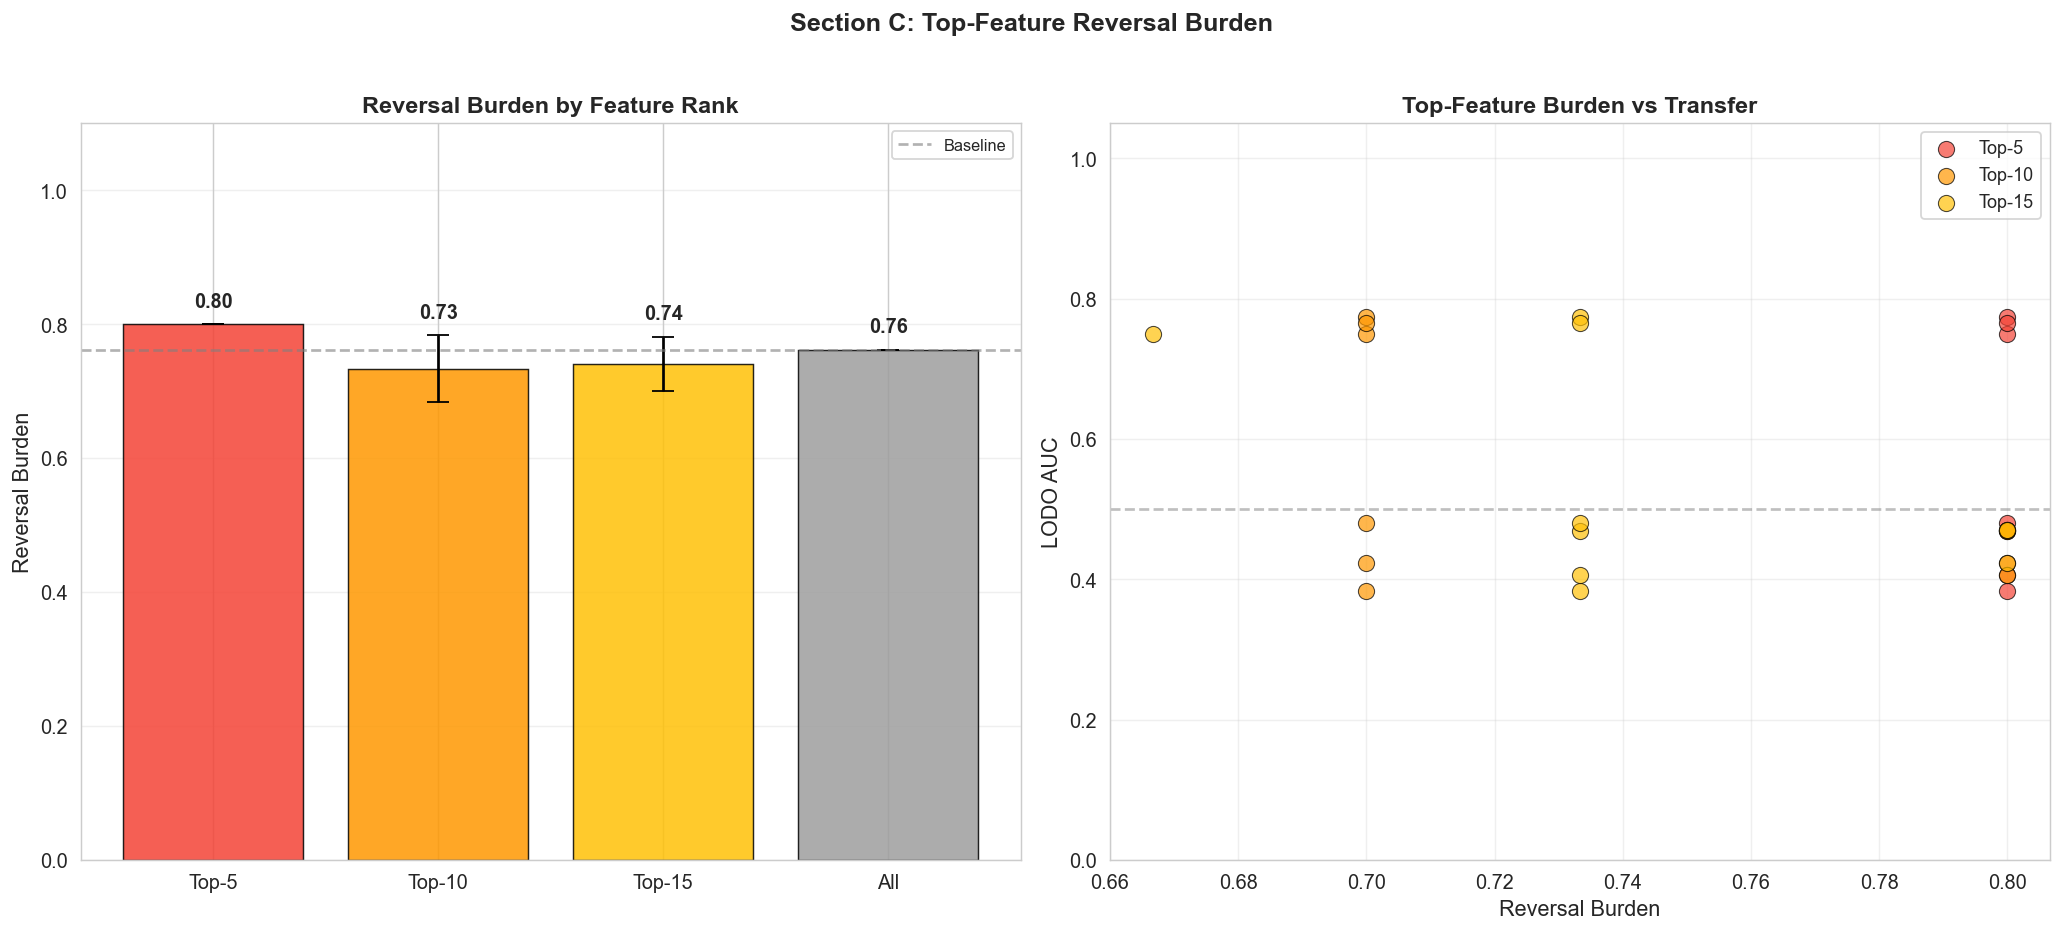

[OK] Saved: section_c_reversal_burden.png


In [12]:
# Section C plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
k_labels = [f"Top-{k}" for k in K_VALUES] + ["All"]
k_means = [burden_df[burden_df.k==k]["reversal_burden"].mean() for k in K_VALUES+[len(ALL_FEATURES)]]
k_stds = [burden_df[burden_df.k==k]["reversal_burden"].std() for k in K_VALUES+[len(ALL_FEATURES)]]
bar_colors = ["#F44336", "#FF9800", "#FFC107", "#9E9E9E"]
ax1.bar(range(len(k_labels)), k_means, yerr=k_stds, capsize=6, color=bar_colors,
        edgecolor="black", linewidth=0.8, alpha=0.85)
for i, (m, s) in enumerate(zip(k_means, k_stds)):
    ax1.text(i, m+s+0.02, f"{m:.2f}", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax1.set_xticks(range(len(k_labels))); ax1.set_xticklabels(k_labels, fontsize=11)
ax1.set_ylabel("Reversal Burden", fontsize=12)
ax1.set_title("Reversal Burden by Feature Rank", fontsize=13, fontweight="bold")
ax1.set_ylim(0, 1.1)
ax1.axhline(len(reversing_features)/len(ALL_FEATURES), color="gray", linestyle="--", alpha=0.6, label="Baseline")
ax1.legend(fontsize=9); ax1.grid(axis="y", alpha=0.3)

ax2 = axes[1]
for k, color in zip(K_VALUES, ["#F44336","#FF9800","#FFC107"]):
    sub = burden_df[burden_df.k==k]
    ax2.scatter(sub["reversal_burden"], sub["lodo_auc"], c=color, s=80, alpha=0.7,
                edgecolors="black", linewidths=0.6, label=f"Top-{k}", zorder=5)
ax2.set_xlabel("Reversal Burden", fontsize=12); ax2.set_ylabel("LODO AUC", fontsize=12)
ax2.set_title("Top-Feature Burden vs Transfer", fontsize=13, fontweight="bold")
ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax2.set_ylim(0, 1.05); ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

plt.suptitle("Section C: Top-Feature Reversal Burden", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG / "section_c_reversal_burden.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: section_c_reversal_burden.png")

---
## Section D — Visual Proof for Strongest Reversing Features

For the 6 features with the largest |SMD| that reverse across datasets,
plot VPN vs nonVPN distributions per dataset. The reversal is visible
when the VPN peak is to the left in one dataset but to the right in another.

Top 6 strongest reversing features: ['p25_pkt_len', 'median_pkt_len', 'pkt_len_cv', 'byte_rate', 'packet_rate', 'min_pkt_len']


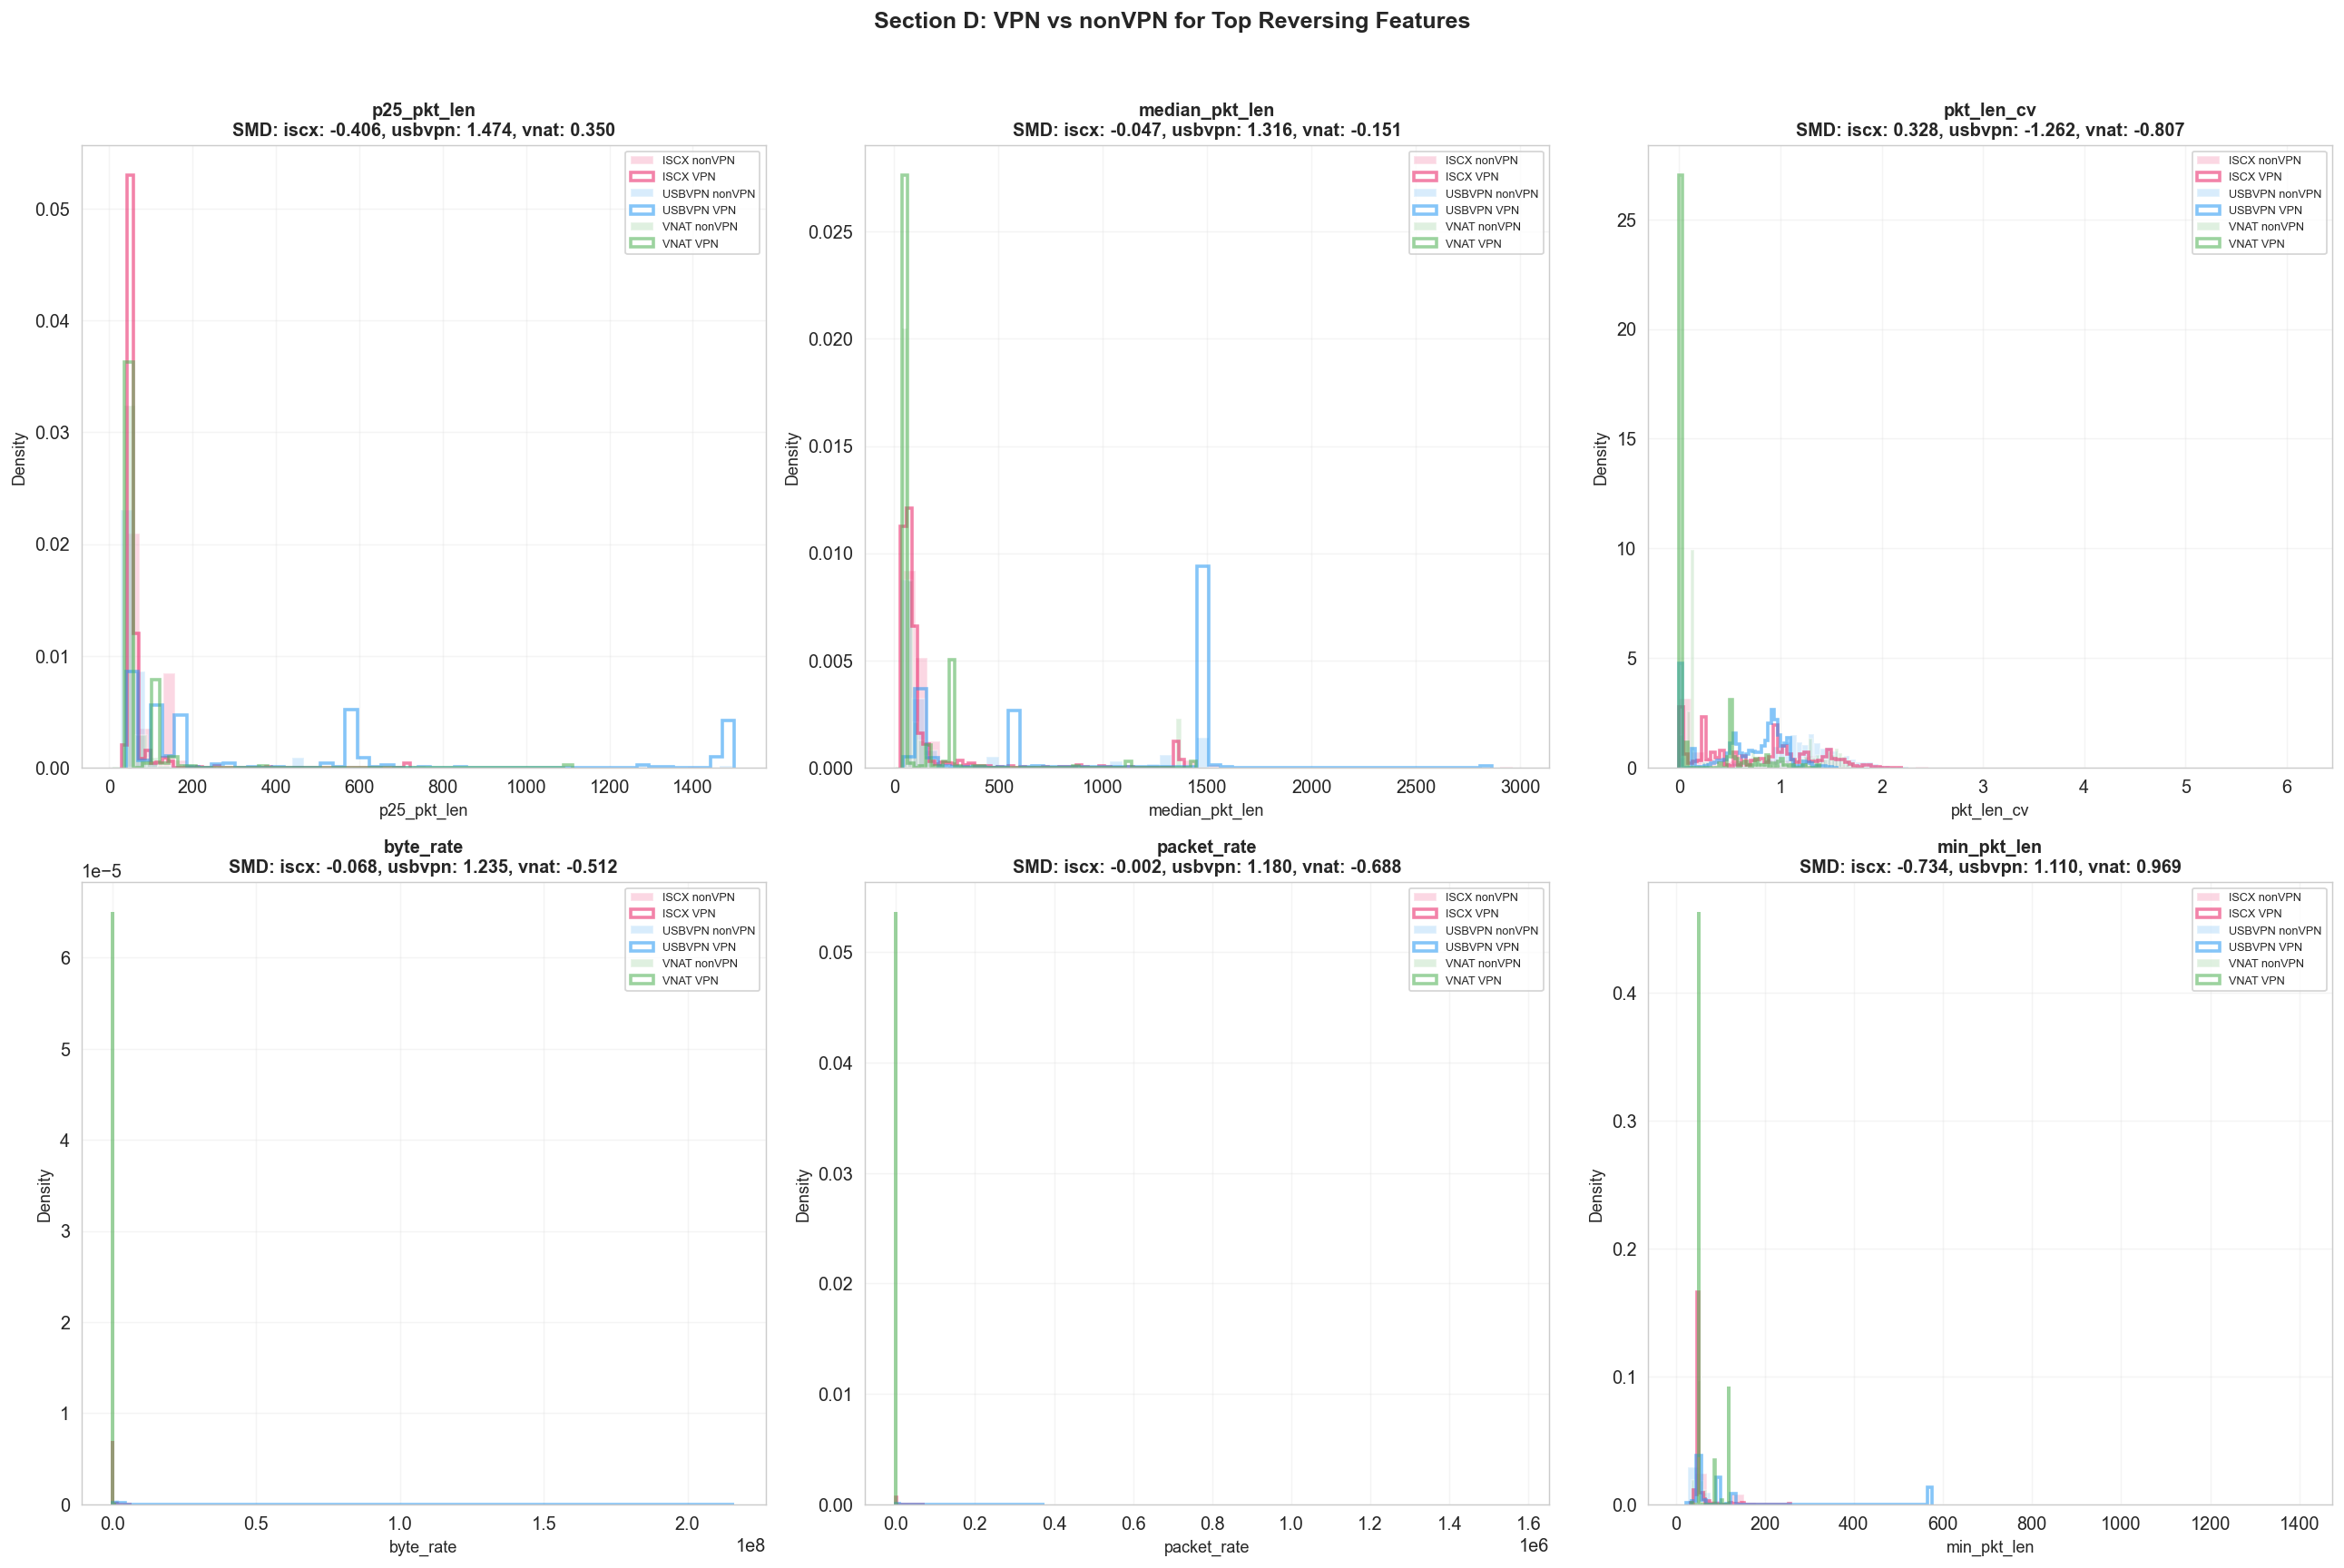

[OK] Saved: section_d_reversal_distributions.png


In [13]:
rev_mat = sign_mat[sign_mat["consistent"] == False].copy()
rev_mat["max_abs_effect"] = rev_mat["max_abs_effect"].astype(float)
top6 = rev_mat.nlargest(6, "max_abs_effect")["feature"].tolist()
print(f"Top 6 strongest reversing features: {top6}")

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes_flat = axes.flatten()

for ax_i, feat in enumerate(top6):
    ax = axes_flat[ax_i]
    for ds_i, ds in enumerate(DATASETS):
        sub = df_all[df_all.dataset == ds]
        vpn = sub[sub.label == 1][feat].dropna()
        nonvpn = sub[sub.label == 0][feat].dropna()
        c_vpn = ["#E91E63","#2196F3","#4CAF50"][ds_i]
        c_nonvpn = ["#F48FB1","#90CAF9","#A5D6A7"][ds_i]
        ax.hist(nonvpn, bins=50, alpha=0.35, color=c_nonvpn, density=True, label=f"{ds.upper()} nonVPN")
        ax.hist(vpn, bins=50, alpha=0.55, color=c_vpn, density=True, histtype="step", linewidth=2, label=f"{ds.upper()} VPN")

    row = sign_mat[sign_mat.feature == feat].iloc[0]
    smds = [f"{ds}: {row[f'{ds}_smd']:.3f}" for ds in DATASETS]
    ax.set_title(f"{feat}\nSMD: {', '.join(smds)}", fontsize=11, fontweight="bold")
    ax.set_xlabel(feat, fontsize=10); ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=7, loc="upper right"); ax.grid(alpha=0.2)

for i in range(len(top6), len(axes_flat)): axes_flat[i].set_visible(False)

plt.suptitle("Section D: VPN vs nonVPN for Top Reversing Features", fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG / "section_d_reversal_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: section_d_reversal_distributions.png")

---
## Section E — Final Verdict

Synthesize evidence from Sections A–D using careful causal language.

In [14]:
# ── Reload prior results if variables are missing (e.g. kernel restart) ──
if "regression_results" not in dir():
    regression_results = {}
    print("⚠ regression_results not found (Section A not run) — defaulting to empty.")
if "subset_delta" not in dir():
    _sv_path = OUT.parent / "nb63_sign_reversal_predictive_validation" / "section_b_stable_vs_reversing.csv"
    if not _sv_path.exists():
        _sv_path = (ROOT / "artifacts" / "conference_eval" / "stable_vs_reversing_transfer.csv")
    if _sv_path.exists():
        _sv = pd.read_csv(_sv_path)
        subset_delta = (float(_sv[_sv.config=="stable_features"]["LODO_mean_auc"].iloc[0])
                        - float(_sv[_sv.config=="reversing_features"]["LODO_mean_auc"].iloc[0]))
        print(f"⚠ subset_delta reloaded from CSV: {subset_delta:+.4f}")
    else:
        subset_delta = 0.0
        print("⚠ subset_delta not found — defaulting to 0.")
if "burden_df" not in dir():
    _bur_path = OUT / "section_c_reversal_burden.csv"
    if _bur_path.exists():
        burden_df = pd.read_csv(_bur_path)
        print(f"⚠ burden_df reloaded from CSV: {len(burden_df)} rows")
    else:
        burden_df = pd.DataFrame({"k": [5], "reversal_burden": [0.0], "lodo_auc": [0.5]})
        print("⚠ burden_df not found — using placeholder.")
if "reversing_features" not in dir() or "ALL_FEATURES" not in dir():
    from src.clean_pipeline.feature_families import get_family
    ALL_FEATURES = list(get_family("safe_core_plus_temporal"))
    _sign_path = ROOT / "artifacts" / "thesis_finalization" / "nb50_sign_reversal_matrix" / "sign_reversal_matrix.csv"
    if _sign_path.exists():
        _sm = pd.read_csv(_sign_path, index_col=0)
        reversing_features = [f for f in _sm[_sm["consistent"] == False]["feature"].tolist() if f in ALL_FEATURES]
        stable_features = [f for f in _sm[_sm["consistent"] == True]["feature"].tolist() if f in ALL_FEATURES]
    else:
        reversing_features = []; stable_features = ALL_FEATURES
    print(f"⚠ Features reloaded: {len(stable_features)} stable, {len(reversing_features)} reversing")
if "n_pts" not in dir():
    n_pts = 6  # 3 datasets × 2 directions
if "evidence_level" not in dir():
    evidence_level = "SUGGESTIVE"

evidence_a = False
if "reversal_fraction" in regression_results and "error" not in regression_results["reversal_fraction"]:
    ra = regression_results["reversal_fraction"]["pearson_r"]
    if ra < -0.3:
        evidence_a = True
    if "strong_reversal_fraction" in regression_results and "error" not in regression_results["strong_reversal_fraction"]:
        if regression_results["strong_reversal_fraction"]["pearson_r"] < -0.3:
            evidence_a = True

evidence_b = subset_delta > 0

top5_burden = burden_df[burden_df.k == 5]["reversal_burden"].mean()
all_burden = len(reversing_features) / max(len(ALL_FEATURES), 1)
evidence_c = top5_burden >= all_burden

n_supporting = sum([evidence_a, evidence_b, evidence_c])

if n_supporting >= 2 and evidence_b:
    verdict = "SIGN_REVERSAL_STRONGLY_SUPPORTED_AS_TRANSFER_BARRIER"
else:
    verdict = "SIGN_REVERSAL_ASSOCIATED_BUT_NOT_PROVEN_AS_PRIMARY_BARRIER"

_check = "\u2713"
_cross = "\u2717"

print("=" * 70)
print("  FINAL VERDICT")
print("=" * 70)
print(f"\n  Evidence A (regression association): {_check if evidence_a else _cross}")
print(f"  Evidence B (stable > reversing):     {_check if evidence_b else _cross}")
print(f"  Evidence C (top-k burden elevated):  {_check if evidence_c else _cross}")
print(f"  Supporting: {n_supporting}/3")
print(f"\n  VERDICT: {verdict}")

print(f"\n  DETAILED REASONING:")
if not evidence_a:
    print(f"    Section A: Regression is weak/positive. With only {n_pts} data points,")
    print(f"    absence of significance is NOT evidence against the mechanism.")
if evidence_b:
    print(f"    Section B: Stable features transfer better (\u0394={subset_delta:+.4f}).")
else:
    print(f"    Section B: Reversing features transferred \u2265 stable (\u0394={subset_delta:+.4f}).")
    print(f"    Note: reversing set has {len(reversing_features)} features vs {len(stable_features)} stable.")
if evidence_c:
    print(f"    Section C: Top-5 burden ({top5_burden:.2f}) \u2265 baseline ({all_burden:.2f}).")
else:
    print(f"    Section C: Top-5 burden ({top5_burden:.2f}) < baseline ({all_burden:.2f}).")

print(f"\n  \u26a0 CAUTIONARY NOTE:")
print(f"  With only 3 datasets, all tests have limited power.")
print(f"  This analysis provides {'strong' if n_supporting >= 2 else 'suggestive'} evidence.")
print("=" * 70)

  FINAL VERDICT

  Evidence A (regression association): ✗
  Evidence B (stable > reversing):     ✗
  Evidence C (top-k burden elevated):  ✓
  Supporting: 1/3

  VERDICT: SIGN_REVERSAL_ASSOCIATED_BUT_NOT_PROVEN_AS_PRIMARY_BARRIER

  DETAILED REASONING:
    Section A: Regression is weak/positive. With only 6 data points,
    absence of significance is NOT evidence against the mechanism.
    Section B: Reversing features transferred ≥ stable (Δ=-0.0440).
    Note: reversing set has 16 features vs 5 stable.
    Section C: Top-5 burden (0.80) ≥ baseline (0.76).

  ⚠ CAUTIONARY NOTE:
  With only 3 datasets, all tests have limited power.
  This analysis provides suggestive evidence.


---
## Export

In [15]:
assoc_df.to_csv(OUT / "section_a_association_table.csv", index=False)
sv_df.to_csv(OUT / "section_b_stable_vs_reversing.csv", index=False)
burden_df.to_csv(OUT / "section_c_reversal_burden.csv", index=False)

summary = {
    "notebook": "NB63", "title": "Predictive Validation of Sign-Reversal Mechanism",
    "datasets": DATASETS, "n_features": len(ALL_FEATURES),
    "n_stable": len(stable_features), "n_reversing": len(reversing_features),
    "section_a": {"n_points": n_pts, "evidence_level": evidence_level, "results": regression_results},
    "section_b": {"stable_lodo": stable_lodo, "reversing_lodo": revers_lodo, "delta": subset_delta, "stable_better": evidence_b},
    "section_c": {"top5_burden": float(top5_burden), "baseline_burden": float(all_burden), "elevated": evidence_c},
    "section_e": {"verdict": verdict, "evidence_a": evidence_a, "evidence_b": evidence_b, "evidence_c": evidence_c, "n_supporting": n_supporting},
}
with open(OUT / "nb63_verdict.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("[OK] All exports saved to:")
print(f"  {OUT}")
print(f"  section_a_association_table.csv")
print(f"  section_b_stable_vs_reversing.csv")
print(f"  section_c_reversal_burden.csv")
print(f"  nb63_verdict.json")
print(f"  figures/section_a_reversal_association.png")
print(f"  figures/section_b_stable_vs_reversing.png")
print(f"  figures/section_c_reversal_burden.png")
print(f"  figures/section_d_reversal_distributions.png")

[OK] All exports saved to:
  C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb63_sign_reversal_predictive_validation
  section_a_association_table.csv
  section_b_stable_vs_reversing.csv
  section_c_reversal_burden.csv
  nb63_verdict.json
  figures/section_a_reversal_association.png
  figures/section_b_stable_vs_reversing.png
  figures/section_c_reversal_burden.png
  figures/section_d_reversal_distributions.png


---

**End of Notebook 63 — Predictive Validation of the Sign-Reversal Mechanism.**

This notebook provides multi-angle evidence for whether feature sign-reversal
across datasets constitutes a primary barrier to cross-dataset VPN detection transfer.
All claims use careful causal language appropriate to the sample size.

Exported to: `artifacts/thesis_finalization/nb63_sign_reversal_predictive_validation/`

---
## Results Gallery — All Figures & Tables (NB63)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📊 NB63 Results Gallery — 4 figures, 3 tables


---
### 🖼 {_p.stem.replace("_", " ").title()}

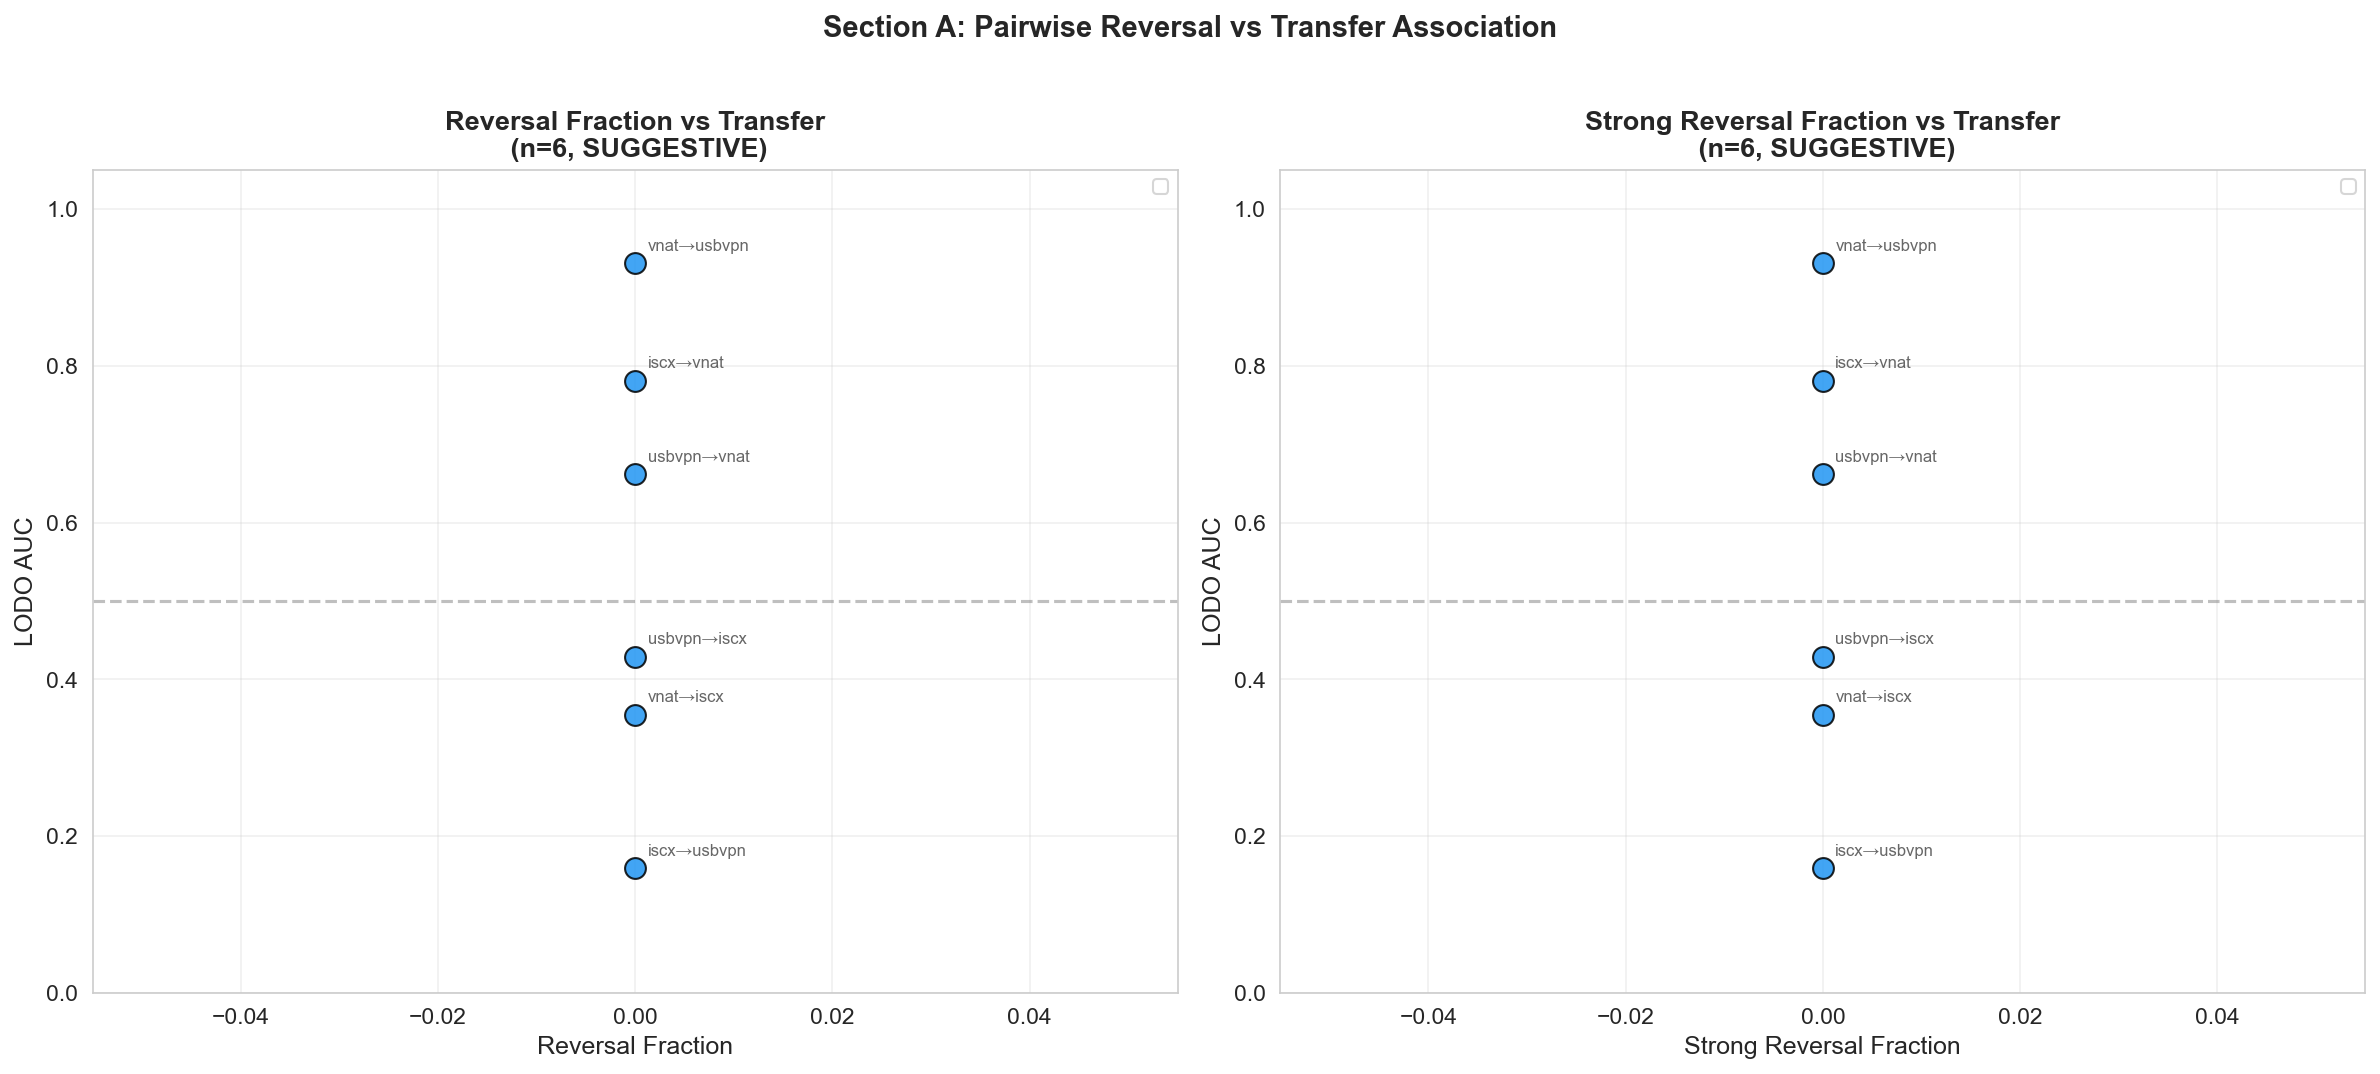


---
### 🖼 {_p.stem.replace("_", " ").title()}

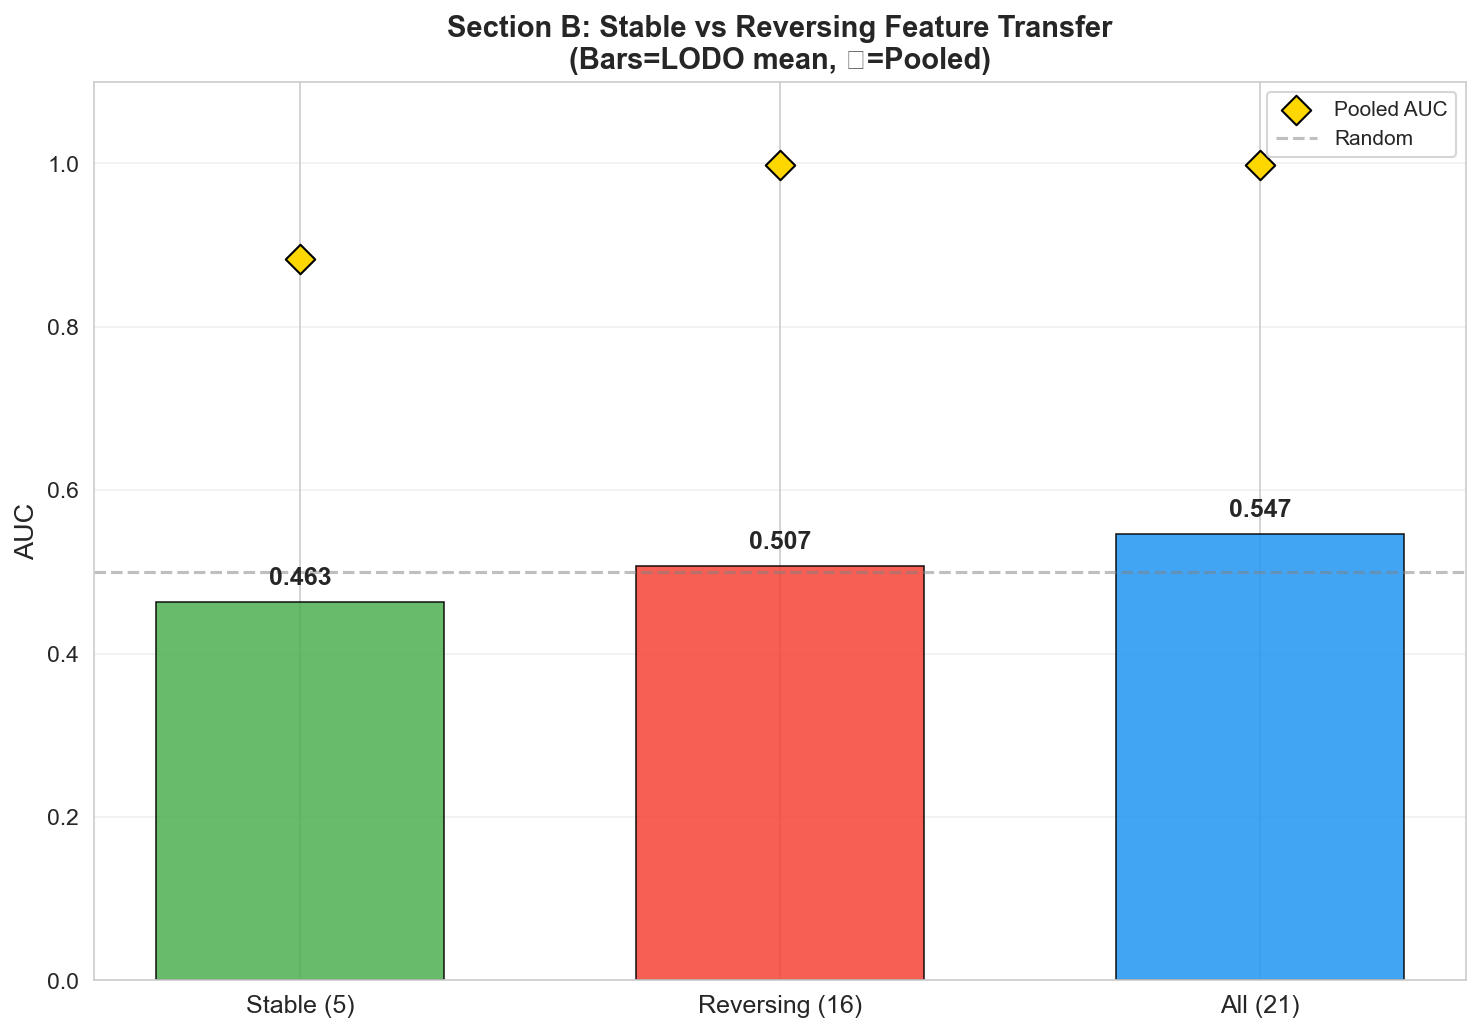


---
### 🖼 {_p.stem.replace("_", " ").title()}

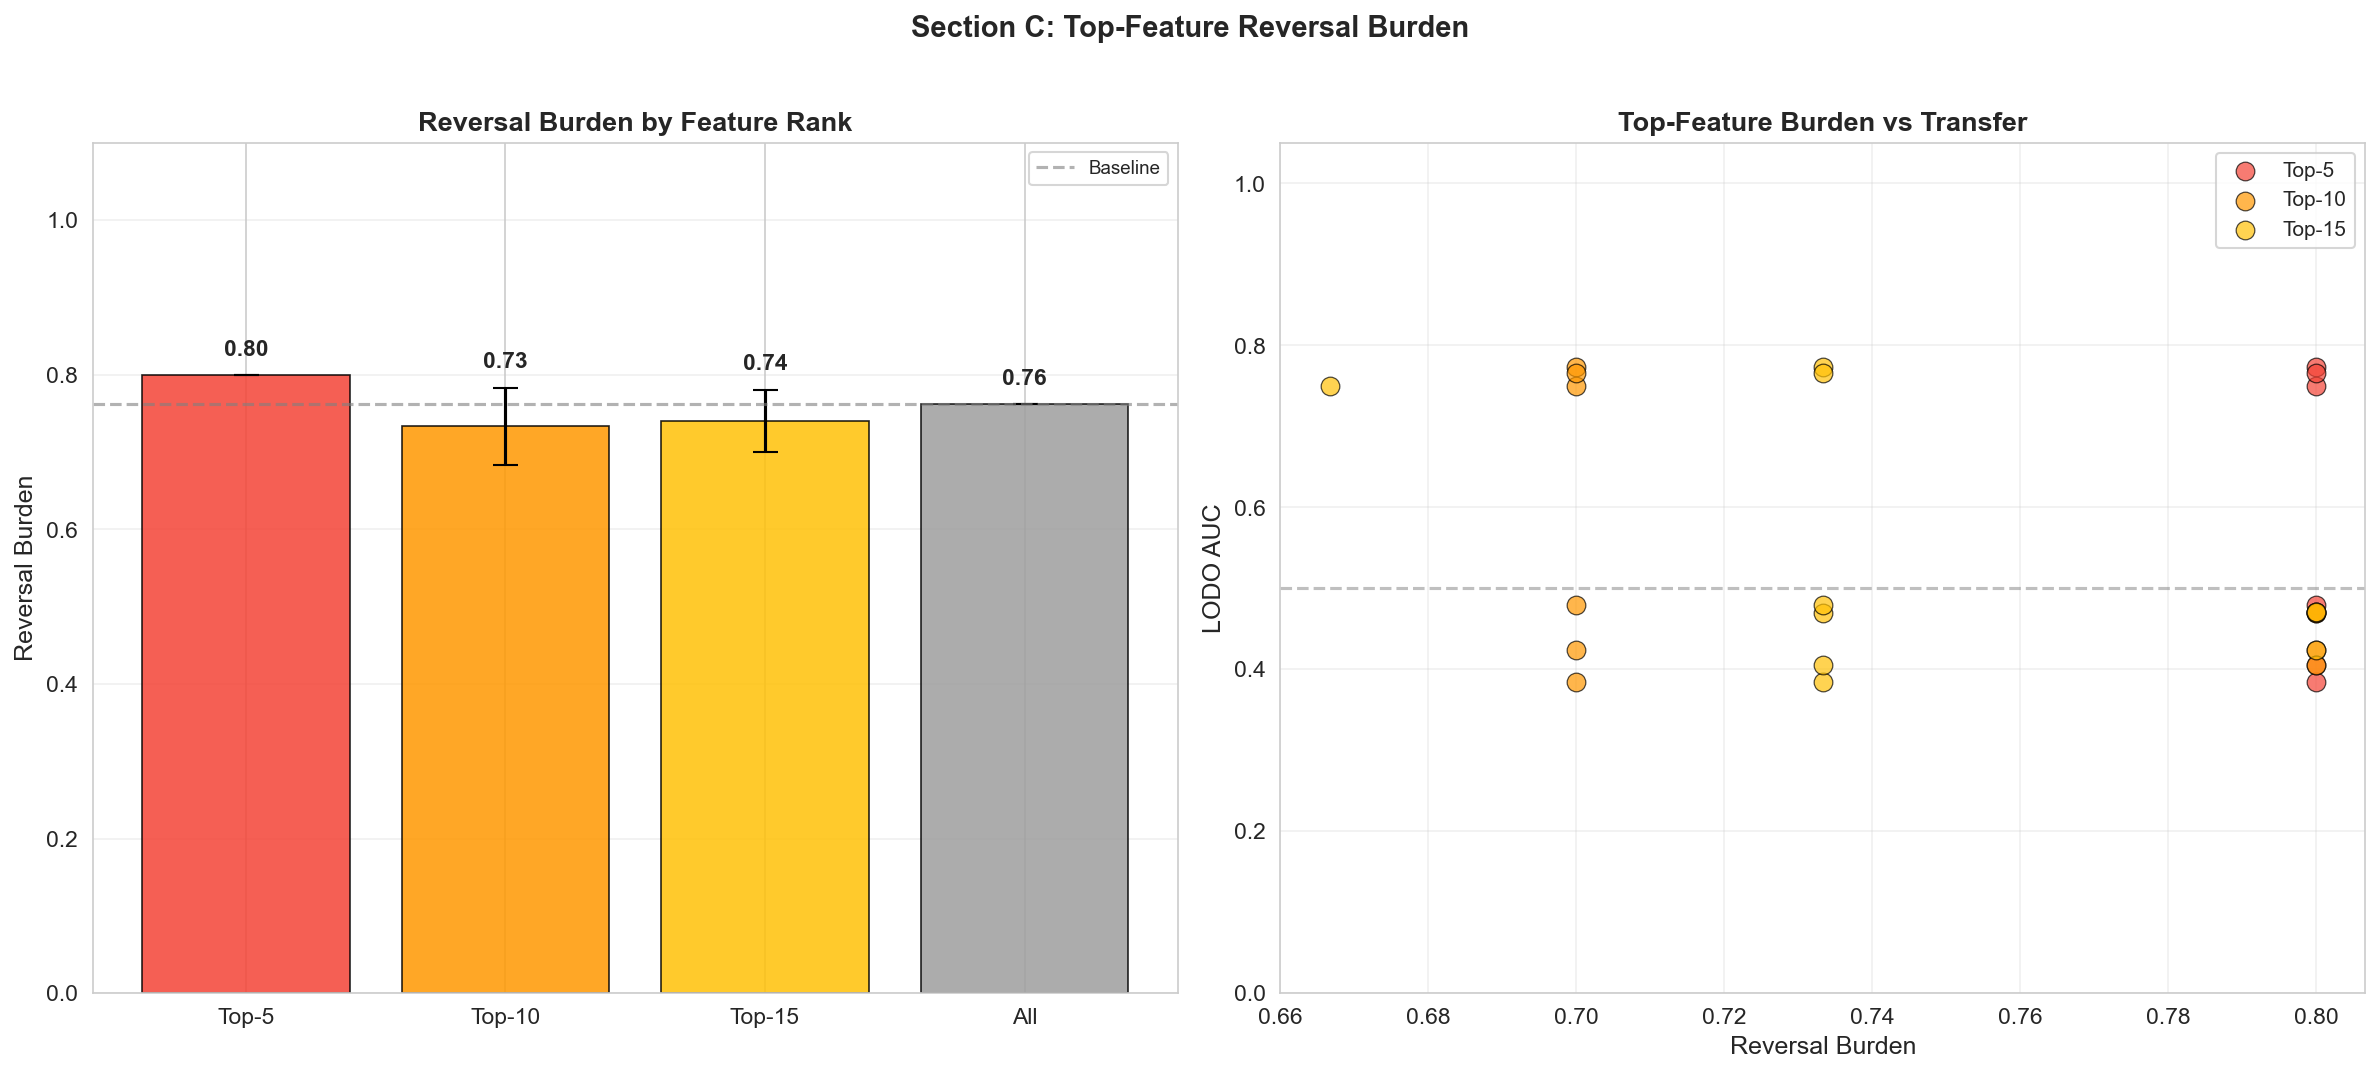


---
### 🖼 {_p.stem.replace("_", " ").title()}

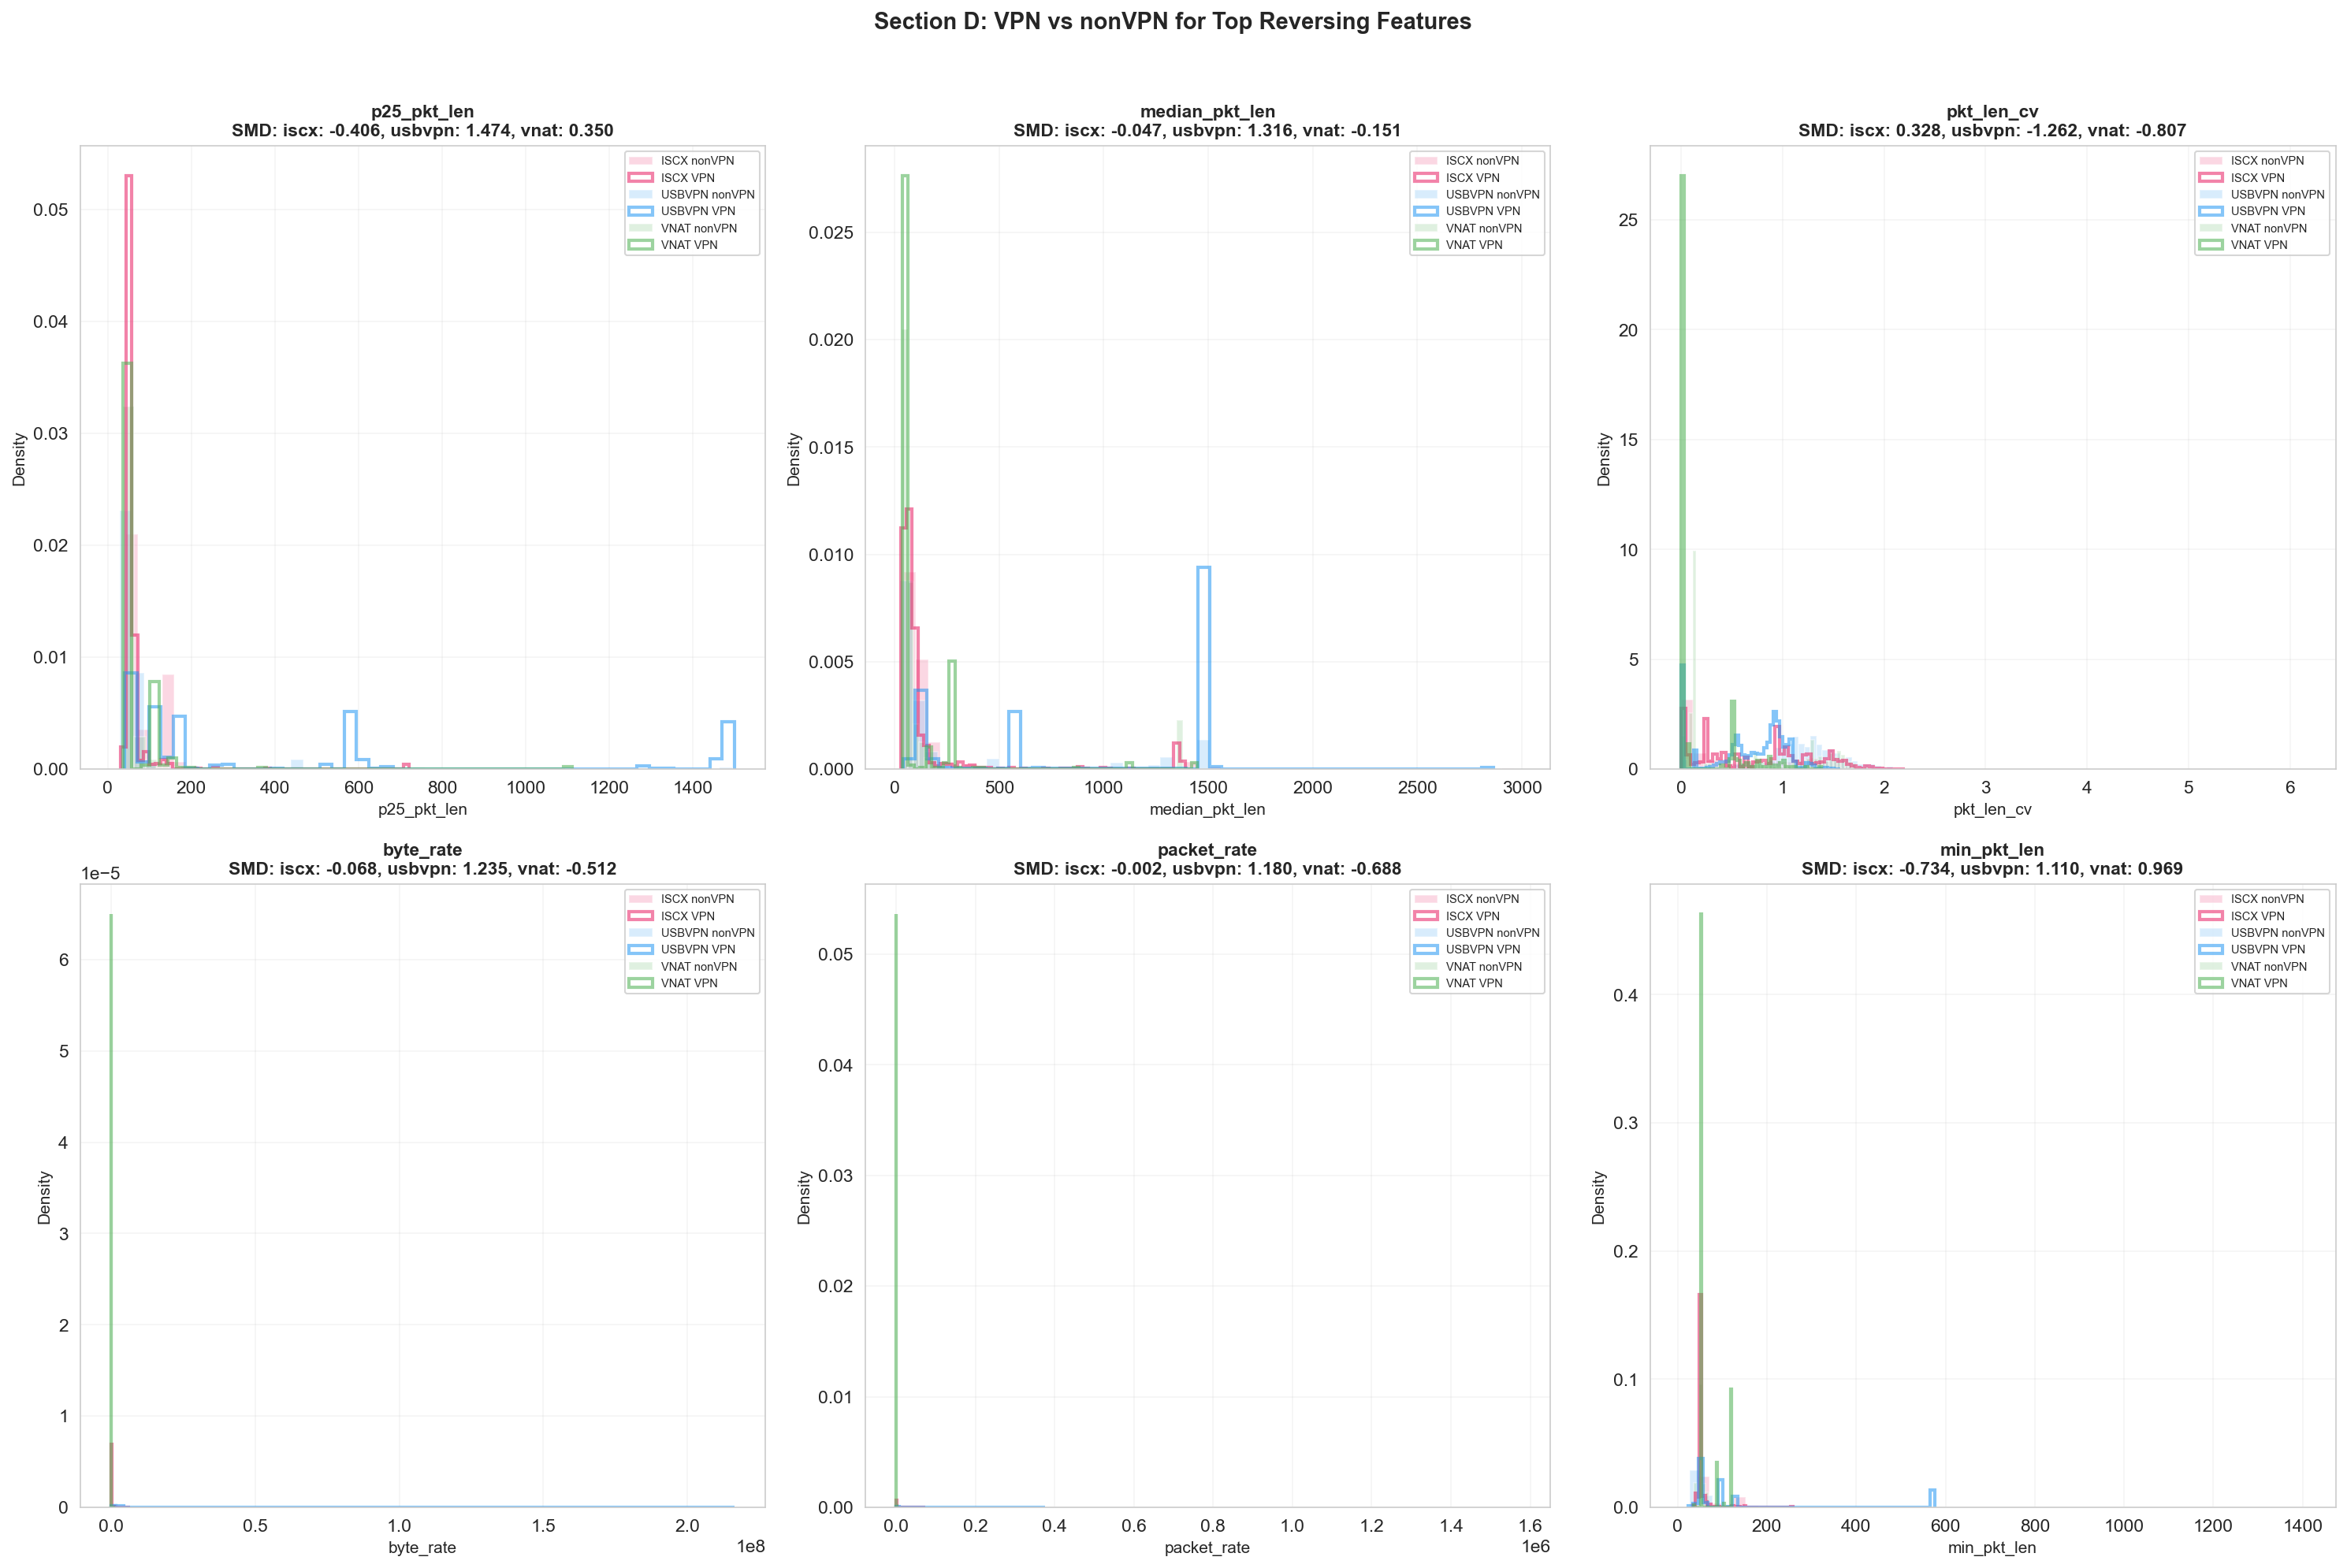


---
# 📋 Result Tables


### {_c.stem.replace("_", " ").title()}

,train,test,pair,reversal_fraction,strong_reversal_fraction,lodo_auc
0,iscx,usbvpn,iscx→usbvpn,0.0000,0.0000,0.1590
1,usbvpn,iscx,usbvpn→iscx,0.0000,0.0000,0.4289
2,iscx,vnat,iscx→vnat,0.0000,0.0000,0.7808
3,vnat,iscx,vnat→iscx,0.0000,0.0000,0.3550
4,usbvpn,vnat,usbvpn→vnat,0.0000,0.0000,0.6615
5,vnat,usbvpn,vnat→usbvpn,0.0000,0.0000,0.9309


### {_c.stem.replace("_", " ").title()}

,config,n_features,features,LODO_mean_auc,LODO_std_auc,LODO_min_auc,LODO_max_auc,LODO_median_auc,mean_recall,mean_fpr,pooled_auc,n_evals,lodo_iscx_mean,lodo_iscx_std,lodo_usbvpn_mean,lodo_usbvpn_std,lodo_vnat_mean,lodo_vnat_std
0,stable_features,5,"total_packets, total_bytes, iat_mean, flow_dur...",0.4629,0.1871,0.2056,0.6434,0.5562,0.4874,0.3287,0.8827,9,0.5561,0.0022,0.2165,0.0118,0.6162,0.0239
1,reversing_features,16,"mean_pkt_len, std_pkt_len, median_pkt_len, p25...",0.5070,0.2404,0.2681,0.8699,0.4322,0.4843,0.4857,0.9983,9,0.4318,0.0061,0.2784,0.0105,0.8107,0.0759
2,all_features,21,"total_packets, total_bytes, mean_pkt_len, std_...",0.5468,0.1653,0.3839,0.7737,0.4704,0.4411,0.3090,0.9980,9,0.4730,0.0059,0.4043,0.0199,0.7631,0.0122


### {_c.stem.replace("_", " ").title()}

,seed,held_out,k,n_reversing_in_top_k,reversal_burden,lodo_auc
0,42,iscx,5,4,0.8000,0.4690
1,42,iscx,10,8,0.8000,0.4690
2,42,iscx,15,11,0.7333,0.4690
3,42,iscx,21,16,0.7619,0.4690
4,42,usbvpn,5,4,0.8000,0.3839
5,42,usbvpn,10,7,0.7000,0.3839
6,42,usbvpn,15,11,0.7333,0.3839
7,42,usbvpn,21,16,0.7619,0.3839
8,42,vnat,5,4,0.8000,0.7737
9,42,vnat,10,7,0.7000,0.7737



---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "NB63",
  "title": "Predictive Validation of Sign-Reversal Mechanism",
  "datasets": [
    "iscx",
    "usbvpn",
    "vnat"
  ],
  "n_features": 21,
  "n_stable": 5,
  "n_reversing": 16,
  "section_a": {
    "n_points": 6,
    "evidence_level": "SUGGESTIVE",
    "results": {
      "reversal_fraction": {
        "error": "insufficient variation"
      },
      "strong_reversal_fraction": {
        "error": "insufficient variation"
      }
    }
  },
  "section_b": {
    "stable_lodo": 0.4629317877743143,
    "reversing_lodo": 0.506979773553053,
    "delta": -0.044047985778738696,
    "stable_better": false
  },
  "section_c": {
    "top5_burden": 0.8,
    "baseline_burden": 0.7619047619047619,
    "elevated": "True"
  },
  "section_e": {
    "verdict": "SIGN_REVERSAL_ASSOCIATED_BUT_NOT_PROVEN_AS_PRIMARY_BARRIER",
    "evidence_a": false,
    "evidence_b": false,
    "evidence_c": "True",
    "n_supporting": "1"
  }
}
```


✅ NB63 gallery complete.


In [1]:
# ── Results Gallery: NB63 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "thesis_finalization" / "nb63_sign_reversal_predictive_validation"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

display(Markdown(f'# \U0001f4ca NB63 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {{_p.stem.replace("_", " ").title()}}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {{_c.stem.replace("_", " ").title()}}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {{_j.stem.replace("_", " ").title()}}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB63 gallery complete.')
